![alt text](image-1.png)

![alt text](image-6.png)

### 1. 실행을 위한 변수 설정

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a1 = 0
a2 = 0
b = 0

#학습률을 정합니다.
lr = 0.01 

#몇 번 반복될지를 설정합니다.
epochs = 2001 

### 2. 경사 하강법

In [6]:
#공부 시간 x1과 과외 시간 x2, 그성적 y의 넘파이 배열을 만듭니다. 
x1 = np.array([2, 4, 6, 8])
x2 = np.array([0, 4, 2, 3])
y = np.array([81, 93, 91, 97]) 

# x 값이 총 몇 개인지 셉니다. x1과 x2의 수가 같으므로 x1만 세겠습니다. 
n=len(x1)

#경사 하강법을 시작합니다.
for i in range(epochs):                  # epoch 수 만큼 반복
    
    y_pred = a1 * x1 + a2 * x2 + b       #예측 값을 구하는 식을 세웁니다
    error = y - y_pred                   #실제 값과 비교한 오차를 error로 놓습니다.
    
    a1_diff = (2/n) * sum(-x1 * (error)) # 오차함수를 a1로 편미분한 값입니다. 
    a2_diff = (2/n) * sum(-x2 * (error)) # 오차함수를 a2로 편미분한 값입니다. 
    b_diff = (2/n) * sum(-(error))       # 오차함수를 b로 편미분한 값입니다. 
    
    a1 = a1 - lr * a1_diff  # 학습률을 곱해 기존의 a1 값을 업데이트합니다.
    a2 = a2 - lr * a2_diff  # 학습률을 곱해 기존의 a2 값을 업데이트합니다.
    b = b - lr * b_diff     # 학습률을 곱해 기존의 b 값을 업데이트합니다.
    
    if i % 100 == 0:        # 100번 반복될 때마다 현재의 a1, a2, b 값을 출력합니다.
        print("epoch=%.f, 기울기1=%.04f, 기울기2=%.04f, 절편=%.04f" % (i, a1, a2, b))
        

epoch=0, 기울기1=9.2800, 기울기2=4.2250, 절편=1.8100
epoch=100, 기울기1=9.5110, 기울기2=5.0270, 절편=22.9205
epoch=200, 기울기1=7.3238, 기울기2=4.2950, 절편=37.8751
epoch=300, 기울기1=5.7381, 기울기2=3.7489, 절편=48.7589
epoch=400, 기울기1=4.5844, 기울기2=3.3507, 절편=56.6800
epoch=500, 기울기1=3.7447, 기울기2=3.0608, 절편=62.4448
epoch=600, 기울기1=3.1337, 기울기2=2.8498, 절편=66.6404
epoch=700, 기울기1=2.6890, 기울기2=2.6962, 절편=69.6938
epoch=800, 기울기1=2.3653, 기울기2=2.5845, 절편=71.9160
epoch=900, 기울기1=2.1297, 기울기2=2.5032, 절편=73.5333
epoch=1000, 기울기1=1.9583, 기울기2=2.4440, 절편=74.7103
epoch=1100, 기울기1=1.8336, 기울기2=2.4009, 절편=75.5670
epoch=1200, 기울기1=1.7428, 기울기2=2.3695, 절편=76.1904
epoch=1300, 기울기1=1.6767, 기울기2=2.3467, 절편=76.6441
epoch=1400, 기울기1=1.6286, 기울기2=2.3301, 절편=76.9743
epoch=1500, 기울기1=1.5936, 기울기2=2.3180, 절편=77.2146
epoch=1600, 기울기1=1.5681, 기울기2=2.3092, 절편=77.3895
epoch=1700, 기울기1=1.5496, 기울기2=2.3028, 절편=77.5168
epoch=1800, 기울기1=1.5361, 기울기2=2.2982, 절편=77.6095
epoch=1900, 기울기1=1.5263, 기울기2=2.2948, 절편=77.6769
epoch=2000, 기울기1=1.5191, 기울기2=2.2

In [7]:
#실제 점수와 예측 된 점수를 출력합니다.
print("실제 점수:", y)
print("예측 점수:", y_pred)

실제 점수: [81 93 91 97]
예측 점수: [80.76387645 92.97153922 91.42520875 96.7558749 ]


## 5-1. 텐서플로에서 실행하는 선형 회귀 모델

### 1.환경 준비

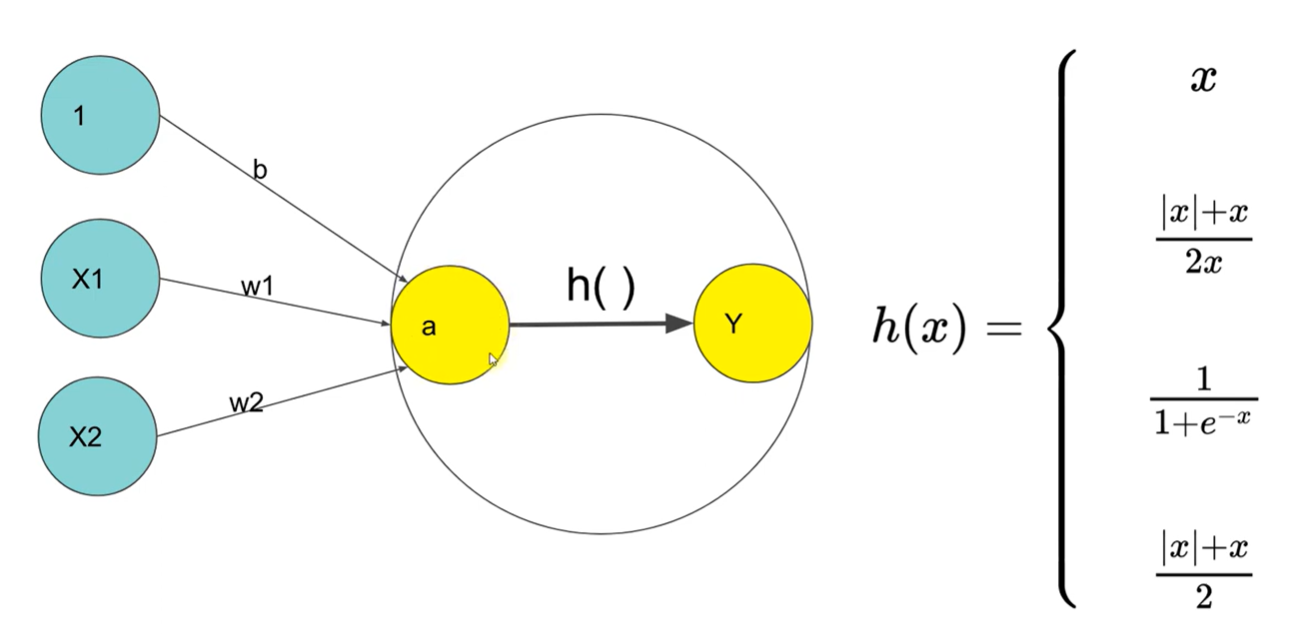

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [2]:
x = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 

### 3. 모델 실행

In [3]:
model = Sequential()

# 출력 값, 입력 변수, 분석 방법에 맞게끔 모델을 설정합니다. 
model.add(Dense(1, input_dim=1, activation='linear'))

# 오차 수정을 위해 경사 하강법(sgd)을, 오차의 정도를 판단하기 위해 평균 제곱 오차(mse)를 사용합니다. 
model.compile(optimizer='sgd', loss='mse')

# 오차를 최소화하는 과정을 2000번 반복합니다.
model.fit(x, y, epochs=2000)

Epoch 1/2000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 7520.1597
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 1939.5663
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1114.5552
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 988.0552
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 964.1837
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 955.4200
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 948.9093
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 942.7632
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 936.7045
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 930.6920
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 924.7192
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 918.7853
Epoch 13/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 912.8899
Epoch 14/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 907.0327
Epoch 15/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

### 4. 그래프로 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


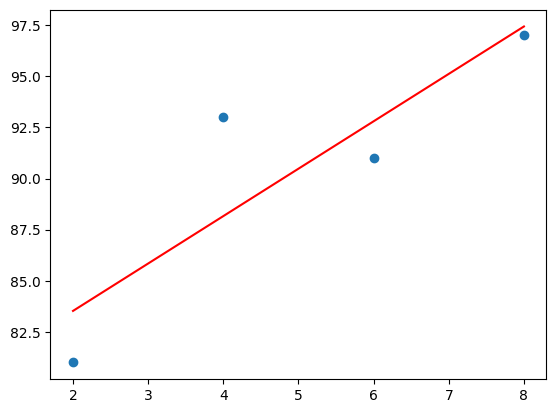

In [11]:
plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')    # 예측 결과를 그래프로 나타냅니다.
plt.show()

### 5. 모델 테스트

In [12]:
#임의의 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.

hour = 7
prediction = model.predict(np.array([hour]))

print("%.f시간을 공부할 경우의 예상 점수는 %.02f점입니다" % (hour, prediction[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
7시간을 공부할 경우의 예상 점수는 95.12점입니다


## 5-2 텐서플로에서 실행하는 다중 선형회귀 모델
## 복수 레이어 구성

### 1.환경 준비

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [14]:
x = np.array([[2, 0], [4, 4], [6, 2], [8, 3]])
y = np.array([81, 93, 91, 97]) 

### 3. 모델 실행

In [ ]:
model = Sequential()

# 입력층 + 은닉층 1
model.add(Dense(2, input_dim=1, activation='linear'))

# 은닉층 2
model.add(Dense(2, activation='linear'))

# 출력층
model.add(Dense(1, activation='linear'))

model.compile(optimizer='sgd', loss='mse')
# 파라미터는 Param는 모델이 학습하는 숫자의 개수
# 👉 즉, 학습 중에 계속 바뀌는 값들
# 🧠 왜 중요한가?

# Param이 많다는 건:

# ✔ 모델이 더 복잡하다
# ✔ 학습할 게 많다
# ✔ 표현력이 크다

# 하지만 동시에:

# ❌ 과적합 위험 증가
# ❌ 학습 느려짐
model.summary()  

model.fit(x, y, epochs=2000)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

# 오차역전파의 이해

🧠 1️⃣ 역전파가 없으면 무슨 일이 벌어지냐?

딥러닝 모델은 결국 이런 문제를 풀고 있어:

min
W,b
	​

L(W,b)

👉 즉 “W, b를 찾아서 loss를 최소화”

❌ 역전파가 없으면

이걸 푸는 방법이 없어짐.

그래서 가능한 방법은:

1) 무식한 방법 (Brute Force)
W, b 값을 하나씩 바꿔가면서
loss 계산 → 제일 작은 값 찾기

# 👉 문제: 경우의 수가 폭발함

![alt text](image-8.png)
![alt text](image-7.png)

https://better-tomorrow.tistory.com/entry/%EC%8B%A0%EA%B2%BD%EB%A7%9D-%EC%A0%95%EB%A6%AC-9-%EC%97%B0%EC%87%84-%EB%B2%95%EC%B9%99-chain-rule

https://compmath.korea.ac.kr/deeplearning/BackPropagation.html